# Euler vs Euler-Cromer Method for Oscillatory Problems

We simulate the simple harmonic oscillator: x'' = -x

This means: acceleration = -x (like a spring)

Initial conditions: x(0) = 1, v(0) = 0

Exact solution: x(t) = cos(t), v(t) = -sin(t)

Energy = 0.5 * (v^2 + x^2) = 0.5 always (conserved)

In [9]:
import numpy as np
import matplotlib.pyplot as plt

## Euler Method

Update rules:
- v(n+1) = v(n) - dt * x(n)
- x(n+1) = x(n) + dt * v(n)   <-- uses OLD velocity

In [10]:


def euler(x0, v0, dt, total_time):
    t = np.arange(0, total_time, dt)
    x = np.zeros(len(t))
    v = np.zeros(len(t))
    
    x[0], v[0] = x0, v0
    
    for i in range(len(t) - 1):
        v[i+1] = v[i] - dt * x[i]
        x[i+1] = x[i] + dt * v[i]
    
    E = 0.5 * (v**2 + x**2)
    
    return t, x, E

## Euler-Cromer Method

Update rules:
- v(n+1) = v(n) - dt * x(n)
- x(n+1) = x(n) + dt * v(n+1)   <-- uses NEW velocity

Only one small change from Euler: use the updated velocity to update position.

In [11]:
import numpy as np

def euler_cromer(x0, v0, dt, total_time):
    t = np.arange(0, total_time, dt)
    x = np.zeros(len(t))
    v = np.zeros(len(t))
    
    x[0], v[0] = x0, v0
    
    for i in range(len(t) - 1):
        v[i+1] = v[i] - dt * x[i]      # update velocity first
        x[i+1] = x[i] + dt * v[i+1]    # use NEW velocity
    
    E = 0.5 * (v**2 + x**2)
    
    return t, x, E

## Plot 1: x(t) for three step sizes - Euler Method

We use dt = 0.01, 0.1, 0.5 and compare with exact solution cos(t).

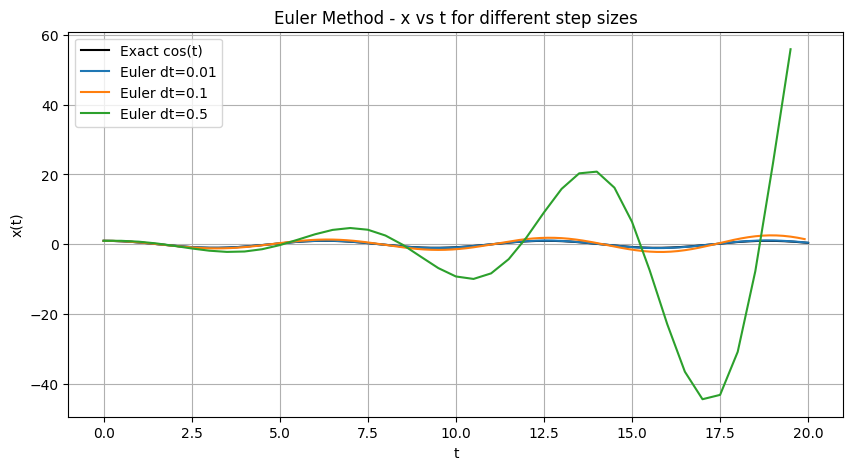

In [12]:
x0 = 1.0
v0 = 0.0
total_time = 20.0

step_sizes = [0.01, 0.1, 0.5]

# exact solution
t_exact = np.linspace(0, total_time, 1000)
x_exact = np.cos(t_exact)

plt.figure(figsize=(10, 5))
plt.plot(t_exact, x_exact, 'k-', label='Exact cos(t)')

for dt in step_sizes:
    t_list, x_list, _ = euler(x0, v0, dt, total_time)
    plt.plot(t_list, x_list, label=f'Euler dt={dt}')

plt.xlabel('t')
plt.ylabel('x(t)')
plt.title('Euler Method - x vs t for different step sizes')
plt.legend()
plt.grid(True)
plt.show()

## Plot 2: x(t) for three step sizes - Euler-Cromer Method

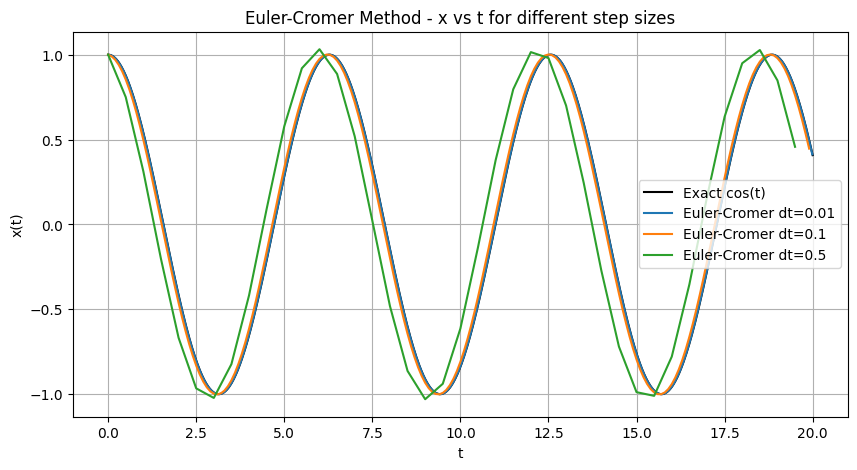

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(t_exact, x_exact, 'k-', label='Exact cos(t)')

for dt in step_sizes:
    t_list, x_list, _ = euler_cromer(x0, v0, dt, total_time)
    plt.plot(t_list, x_list, label=f'Euler-Cromer dt={dt}')

plt.xlabel('t')
plt.ylabel('x(t)')
plt.title('Euler-Cromer Method - x vs t for different step sizes')
plt.legend()
plt.grid(True)
plt.show()

## Plot 3: Energy vs time

Energy E = 0.5 * (v^2 + x^2)

For the exact solution, E = 0.5 always (constant).

We use dt = 0.1 for this plot.

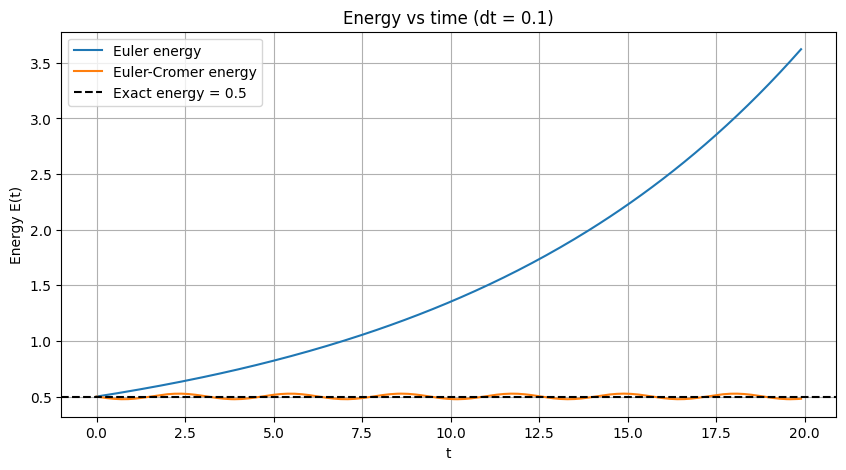

In [14]:
dt = 0.1

t_e, _, E_euler = euler(x0, v0, dt, total_time)
t_ec, _, E_cromer = euler_cromer(x0, v0, dt, total_time)

plt.figure(figsize=(10, 5))
plt.plot(t_e, E_euler, label='Euler energy')
plt.plot(t_ec, E_cromer, label='Euler-Cromer energy')
plt.axhline(y=0.5, color='k', linestyle='--', label='Exact energy = 0.5')
plt.xlabel('t')
plt.ylabel('Energy E(t)')
plt.title('Energy vs time (dt = 0.1)')
plt.legend()
plt.grid(True)
plt.show()

## Observations

**Euler method:**
- The amplitude of x(t) grows over time - the oscillation becomes larger and larger.
- This happens because the Euler method does not conserve energy.
- The energy increases steadily with each time step.
- Smaller dt gives better results, but energy still grows.

**Euler-Cromer method:**
- The amplitude stays roughly constant over time.
- The energy stays close to 0.5 (the correct value) throughout the simulation.
- The small change of using the new velocity instead of the old one makes a big difference.
- Even for dt = 0.1 and dt = 0.5, the oscillation does not blow up.

**Conclusion:**
For oscillatory problems, the Euler-Cromer method is much better than the standard Euler method because it approximately conserves energy. The only difference is using v(n+1) instead of v(n) to update x, but this prevents the energy from growing.